# M5 Hierarchical Forecasting Pipeline

This notebook forecasts monthly Walmart sales at six levels of a hierarchy —
**Total → State → Store → Category → Department → Item** — using three simple
forecasting models, three ways of making those forecasts hierarchically
coherent, and evaluates the results with a single accuracy metric (sMAPE).

**Read the companion notebook `01_eda.ipynb` first.** Every cleanup decision
made here (which items to keep, how far the date range should go, why the
data is aggregated to monthly, why the models use `season_length=12`) is
justified with real numbers and charts over there. This notebook assumes you
have already seen that reasoning and just applies it.

### Repository layout
This notebook lives in `Code/notebooks/`. It imports shared configuration
from `Code/config.py` - the same file `app/streamlit_app.py` reads - so
column names, hierarchy structure, and the reconciler-to-column-suffix
mapping can never silently drift between the pipeline and the dashboard.

### What this notebook produces
1. Three **base forecasts** per series: HistoricAverage (a naive baseline),
   AutoETS (exponential smoothing), and Theta (a decomposition-based method).
2. Three **reconciliation methods** that make those forecasts add up
   correctly through the hierarchy: Bottom-Up, MinTrace, and Top-Down.
3. Accuracy scores (sMAPE) sliced two ways: by hierarchy level, and by
   sales-volume segment (top sellers vs. the long tail).

### Data required
Download from Kaggle (`m5-forecasting-accuracy` competition) into `Code/data/m5/` (see `Code/data/README.md`):
- `sales_train_validation.csv`
- `calendar.csv`

**Reproducibility.** All outputs in this notebook were generated by
executing it top-to-bottom in the `m5_forecast` environment. If you
change the data, `config.py`, or any modelling step, re-run the whole
notebook rather than individual cells - several steps (the item universe
fix in Section 6.3 in particular) depend on state built by earlier cells.


## Contents
1. Imports
2. Configuration
3. sMAPE — the one accuracy metric used everywhere
4. Data Loading
5. Reshape: wide → long, then attach real dates
6. Data Preparation
7. Build the Hierarchy
8. Base Forecasting Models
   - 8.5 Clip Negative Base Forecasts Before Reconciliation
9. Reconciliation
10. Combine Results and Attach Ground Truth
11. Evaluation — Accuracy by Hierarchy Level
12. Evaluation — Accuracy by Volume Segment
13. Negative Forecast Check
14. Sanity Checks
15. Optional Visualisation
16. Export Data for the Dashboard


## 1. Imports

- `statsforecast` fits the three forecasting models, fast, across
  thousands of series at once.
- `hierarchicalforecast` builds the hierarchy (the "summing matrix" that
  says how items roll up into departments, departments into categories,
  and so on) and applies the reconciliation methods.
- `utilsforecast` supplies `smape`, the one accuracy metric used everywhere
  in this notebook, and a plotting helper.


In [1]:
from pathlib import Path
import time
import inspect
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, AutoETS, Theta

from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUpSparse, MinTraceSparse, TopDownSparse
from hierarchicalforecast.evaluation import evaluate as hierarchical_evaluate

from utilsforecast.plotting import plot_series
from utilsforecast import losses as uloss

# AutoETS checks each series' autocorrelation before fitting. Series that
# are constant throughout training (e.g. an item with zero sales the whole
# time) have zero variance, which makes this check divide by zero. This is
# harmless - such series simply fall back to HistoricAverage (see Section
# 14, check [3]) - so the warning is suppressed here to keep the output
# readable. It does NOT suppress errors, only this one specific message.
warnings.filterwarnings("ignore", message="invalid value encountered in divide")

print("Imports OK")


/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2. Configuration

**Why a "Total" root exists.** Without it, the hierarchy is really three
separate trees (CA, TX, WI) with no single top. Top-Down reconciliation is
only mathematically defined when there is one root to distribute downward
from - so a "Total" node is added above State. See `01_eda.ipynb`, Section
5 for the effect this has (before this fix, Top-Down was silently changing
state-level forecasts, which it should never do).

**Why `SEASON_LENGTH = 12`.** The data is monthly, and `01_eda.ipynb`,
Section 7 shows a clear, repeating November/December sales spike every
year. A `season_length` of 12 tells ETS and Theta "look for a pattern that
repeats every 12 points" - without it, both models default to
`season_length=1`, i.e. no seasonality at all, and produce almost flat
forecasts.

**Why these three time windows.** Train ends where Test begins; Test ends
where Live begins. "Live" extends beyond the actual data (which stops in
April 2016) purely to give the pipeline something to write forecasts into -
there is no real ground truth for May/June/July 2016 in this dataset, so
the Live period is never used for evaluation, only for the dashboard.


In [2]:
import sys
sys.path.append(str(Path("..").resolve()))
import config as cfg

# --- Time windows -----------------------------------------------------------
train_test_split_date: str = cfg.TRAIN_TEST_SPLIT_DATE   # train ends, test begins
forecast_start_date: str = cfg.FORECAST_START_DATE       # test ends, live begins
forecast_end_date: str = cfg.FORECAST_END_DATE           # live ends (no real data past Apr 2016)

# --- Column names -------------------------------------------------------------
date_col: str = cfg.DATE_COL
target_col: str = cfg.TARGET_COL
cat_label_col: str = cfg.CAT_LABEL_COL      # will hold "train" / "test" / "live"
id_col: str = cfg.ID_COL                    # hierarchicalforecast's series identifier

# --- Hierarchy columns, Total → ... → Item -----------------------------------
col_total: str = cfg.COL_TOTAL
col_state: str = cfg.COL_STATE
col_store: str = cfg.COL_STORE
col_cat: str = cfg.COL_CAT
col_dept: str = cfg.COL_DEPT
col_item: str = cfg.COL_ITEM

hierarchy_cols: list = cfg.HIERARCHY_COLS

# `spec` tells hierarchicalforecast's aggregate() function which columns
# define each level, from the top down. Built once in config.py so it can
# never drift from hierarchy_cols above, or from what app/streamlit_app.py
# assumes about the hierarchy's shape.
spec: list = cfg.SPEC

# Carries the train/test/live label through the aggregation step. "min" is
# a safe, no-op choice here: since the label only depends on the date (not
# on which item/store it is), every row being aggregated for a given date
# already shares the same label, so "min" just returns that shared value.
exog_vars: dict = cfg.EXOG_VARS

SEASON_LENGTH: int = cfg.SEASON_LENGTH         # monthly data -> yearly seasonality
PERCENTILES: list = cfg.PERCENTILES            # cumulative share of TRAINING volume

# --- Folders -------------------------------------------------------------------
M5_DATA_DIR = cfg.DATA_DIR
cache_raw_dir = cfg.RAW_CACHE_DIR

print("Configuration loaded")
print(f" - Train period : start -> {train_test_split_date}")
print(f" - Test period  : {train_test_split_date} -> {forecast_start_date}")
print(f" - Live period  : {forecast_start_date} -> {forecast_end_date}")
print(f" - Hierarchy    : {' -> '.join(c.replace('_id', '').title() for c in hierarchy_cols)}")


Configuration loaded
 - Train period : start -> 2015-01-01
 - Test period  : 2015-01-01 -> 2016-01-01
 - Live period  : 2016-01-01 -> 2016-07-01
 - Hierarchy    : Total -> State -> Store -> Cat -> Dept -> Item


## 3. sMAPE — the one accuracy metric used everywhere

**The formula:**

$$\text{sMAPE} = \text{mean}\left(\frac{|F - A|}{|F| + |A|}\right) \times 100$$

where $F$ is the forecast and $A$ is the actual value.

**Worked example.** Actual sales = 10, forecast = 12:
- Error: $|12-10| = 2$
- Denominator: $|12|+|10| = 22$
- sMAPE for this point: $2/22 = 0.0909 \rightarrow 9.09\%$

**The zero/zero case.** If both the actual and the forecast are 0 (a dead
item, correctly predicted as dead), the formula would divide 0 by 0. This
is treated as **0% error** - a perfect forecast - rather than undefined.

**Why this scale (0-100%) and not the classic 0-200% version.** Some
textbooks add a `/2` to the denominator, which doubles the whole metric to
a 0-200% scale. Neither version is more "correct" - they're just different
scaling conventions for the same underlying idea. This notebook uses the
0-100% version because it's exactly what `utilsforecast.losses.smape`
computes (confirmed below by printing its source), so there is only ever
one scale in play, instead of two different numbers that look comparable
but aren't.


In [3]:
def smape_pct(actual, forecast) -> float:
    """
    Symmetric Mean Absolute Percentage Error, as a percentage (0-100%).
    Formula: mean( |F - A| / (|F| + |A|) ) * 100
    Points where both actual and forecast are 0 contribute 0 error.
    """
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    denom = np.abs(actual) + np.abs(forecast)
    ratio = np.divide(
        np.abs(forecast - actual), denom,
        out=np.zeros_like(denom), where=denom != 0,
    )
    return float(ratio.mean() * 100)


# Proof that our formula matches the library's formula exactly - same
# |F-A| / (|F|+|A|) fraction, same zero-handling. We just multiply by 100
# afterwards to express it as a percentage, since the library returns the
# raw, unscaled fraction.
print("utilsforecast.losses.smape source (for comparison):")
print(inspect.getsource(uloss.smape))


utilsforecast.losses.smape source (for comparison):
@_base_docstring
def smape(
    df: IntoDataFrameT,
    models: List[str],
    id_col: str = "unique_id",
    target_col: str = "y",
    cutoff_col: str = "cutoff",
) -> IntoDataFrameT:
    """Symmetric Mean Absolute Percentage Error (SMAPE)

    SMAPE measures the relative prediction
    accuracy of a forecasting method by calculating the relative deviation
    of the prediction and the observed value scaled by the sum of the
    absolute values for the prediction and observed value at a
    given time, then averages these devations over the length
    of the series. This allows the SMAPE to have bounds between
    0% and 100% which is desirable compared to normal MAPE that
    may be undetermined when the target is zero."""

    def gen_expr(model):
        abs_err = (nw.col(model) - nw.col(target_col)).abs()
        denominator = _zero_to_nan(nw.col(model).abs() + nw.col(target_col).abs())
        return (abs_err / denominator).ali

## 4. Data Loading

Raw M5 files are large (the sales file alone is ~450k rows x 1919 columns),
so both files are cached to Parquet after the first load. Parquet is a
columnar binary format: much faster to read back than re-parsing a CSV
every time, and it preserves data types (dates stay dates, not strings).


In [4]:
cache_path = cache_raw_dir / "sales_train_validation.parquet"
if not cache_path.is_file():
    print(" Loading sales_train_validation.csv ...")
    df_sales_raw = pd.read_csv(M5_DATA_DIR / "sales_train_validation.csv")
    df_sales_raw.to_parquet(cache_path)
else:
    df_sales_raw = pd.read_parquet(cache_path)
print(f" Loaded sales data ({df_sales_raw.shape[0]:,} rows, {df_sales_raw.shape[1]:,} cols)")

cache_path = cache_raw_dir / "calendar.parquet"
if not cache_path.is_file():
    print(" Loading calendar.csv ...")
    df_calendar = pd.read_csv(M5_DATA_DIR / "calendar.csv", parse_dates=["date"])
    df_calendar.to_parquet(cache_path)
else:
    df_calendar = pd.read_parquet(cache_path)
print(f" Loaded calendar ({df_calendar.shape[0]:,} rows)")


 Loaded sales data (30,490 rows, 1,919 cols)
 Loaded calendar (1,969 rows)


## 5. Reshape: wide → long, then attach real dates

The raw sales file has one row per item-store, and one column per day
(`d_1`, `d_2`, ... `d_1913`) - this is "wide" format. Forecasting tools
expect "long" format instead: one row per (series, date, value). `melt()`
does that reshape. The `calendar.csv` file is what actually maps `d_1`,
`d_2`, etc. to real calendar dates, so it's joined on immediately after.


In [5]:
print(" Melting sales data from wide to long format ...")
start_time = time.time()
meta_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in df_sales_raw.columns if c.startswith("d_")]
df_long = df_sales_raw[meta_cols + day_cols].melt(
    id_vars=meta_cols, value_vars=day_cols, var_name="d", value_name="sales",
)
print(f" Melted in {time.time() - start_time:.2f}s ({df_long.shape[0]:,} rows)")
del df_sales_raw

df_long = df_long.merge(df_calendar[["d", "date"]], on="d", how="left")
df_long.drop(columns=["d", "id"], inplace=True)
df_long["date"] = pd.to_datetime(df_long["date"])
print(f" Calendar joined - date range: {df_long['date'].min().date()} -> {df_long['date'].max().date()}")
del df_calendar


 Melting sales data from wide to long format ...
 Melted in 42.00s (58,327,370 rows)
 Calendar joined - date range: 2011-01-29 -> 2016-04-24


## 6. Data Preparation

Five steps happen here, in order, and the order matters:

1. **Aggregate daily → monthly.** Forecasting monthly instead of daily
   smooths out day-to-day noise and matches the planning horizon most
   retail businesses actually use (see `01_eda.ipynb`, Section 6 for how
   sparse the daily data is at item level - monthly aggregation is one of
   the main ways this pipeline copes with that sparsity).
2. **Drop the partial first calendar month.** Sales data starts
   2011-01-29, so the `2011-01-01` monthly bucket built in step 1 only
   contains 3 real days, not a full January. Left in, this understates
   January sales in one of the four training years, which distorts the
   January seasonal index that `season_length=12` relies on for ETS and
   Theta (see `01_eda.ipynb`, Section 3, for the underlying date-range
   check this relies on). The fix simply excludes any monthly bucket
   before the first *complete* month.
3. **Fix the item universe once, using training data only.** An item that
   first sold *after* the train/test split has no training history - no
   model here could ever have forecast it, so it's removed. Doing this
   now, before anything else is built, means test, live, and evaluation
   automatically end up using the exact same set of items - there is no
   later step where their item sets could quietly drift apart.
4. **Build the full monthly grid.** Every item-store combination needs a
   row for every month, including months with zero sales (so the models
   see the true shape of demand, not a shortened series), and including
   months beyond the real data (so the pipeline has a place to write live
   forecasts into).
5. **Label each row train / test / live**, based on its date.


In [6]:
# --- 6.1 Aggregate daily -> monthly ------------------------------------------
print(" Resampling daily sales to monthly ...")
start_time = time.time()
df_monthly = (
    df_long.groupby(
        [col_state, col_store, col_cat, col_dept, col_item, pd.Grouper(key="date", freq="MS")]
    )["sales"].sum().reset_index()
)
print(f" Resampled in {time.time() - start_time:.2f}s ({df_monthly.shape[0]:,} rows)")
del df_long


 Resampling daily sales to monthly ...
 Resampled in 28.78s (1,951,360 rows)


In [7]:
# --- 6.2 Drop the partial first calendar month -------------------------------
# Sales data starts 2011-01-29 (see 01_eda.ipynb, Section 3), so the
# 2011-01-01 monthly bucket built above only contains 3 real days, not a
# full January. Left in, this corrupts the January seasonal index for
# ETS/Theta, since season_length=12 would see a near-empty January in one
# of the four training years. This keeps every OTHER month untouched -
# only the single, genuinely partial first bucket is dropped.
first_full_month = df_monthly["date"].min() + pd.offsets.MonthBegin(1)
n_before = len(df_monthly)
df_monthly = df_monthly[df_monthly["date"] >= first_full_month].copy()
print(f" Dropped {n_before - len(df_monthly):,} rows from the partial first month "
      f"(excluding monthly buckets before {first_full_month.date()})")


 Dropped 30,490 rows from the partial first month (excluding monthly buckets before 2011-02-01)


In [8]:
# --- 6.3 Fix the item universe, using TRAINING data only ---------------------
# "Active" = had at least one month of non-zero sales before the train/test
# split. Items that never sold anything in that window are dropped, because
# no amount of modelling could forecast a series with zero training history.
train_active_items = (
    df_monthly.loc[
        (df_monthly["date"] < train_test_split_date) & (df_monthly["sales"] != 0),
        col_item,
    ].unique()
)
n_items_before = df_monthly[col_item].nunique()
df_monthly = df_monthly[df_monthly[col_item].isin(train_active_items)].copy()
n_items_after = df_monthly[col_item].nunique()
print(f" Item universe fixed at the training boundary ({train_test_split_date})")
print(f"   - items before : {n_items_before:,}")
print(f"   - items after  : {n_items_after:,}")
print(f"   - dropped      : {n_items_before - n_items_after:,} (no sales before the split)")


 Item universe fixed at the training boundary (2015-01-01)
   - items before : 3,049
   - items after  : 3,024
   - dropped      : 25 (no sales before the split)


In [9]:
# --- 6.4 Build the complete monthly grid -------------------------------------
# Cross-join every remaining item-store combination with every month from
# the earliest date in the data out to forecast_end_date, then fill any
# missing (item, month) combination with 0 sales. Months past the real
# data (after ~April 2016) get 0 here purely as a placeholder - there is
# no real sales data for them, and they are never used for evaluation.
print(" Building complete monthly grid ...")
start_time = time.time()
all_dates = pd.date_range(start=df_monthly["date"].min(), end=forecast_end_date, freq="MS")
all_items = df_monthly[[col_state, col_store, col_cat, col_dept, col_item]].drop_duplicates()
full_grid = all_items.merge(pd.DataFrame({"date": all_dates}), how="cross")
df_grid = full_grid.merge(
    df_monthly, on=[col_state, col_store, col_cat, col_dept, col_item, "date"], how="left",
)
df_grid["sales"] = df_grid["sales"].fillna(0).astype(np.float32)
df_grid["date"] = df_grid["date"].astype("datetime64[us]")
df_grid[col_total] = "Total"   # constant column - the root of the hierarchy
print(f" Grid built in {time.time() - start_time:.2f}s ({df_grid.shape[0]:,} rows)")
del df_monthly, full_grid, all_items


 Building complete monthly grid ...
 Grid built in 1.46s (1,995,840 rows)


In [10]:
# --- 6.5 Label every row train / test / live, by date ------------------------
def generate_cat_label(df, date_col, train_end, test_end, live_end, label_col="_cat"):
    conditions = [
        df[date_col] < pd.Timestamp(train_end),
        (df[date_col] >= pd.Timestamp(train_end)) & (df[date_col] < pd.Timestamp(test_end)),
        (df[date_col] >= pd.Timestamp(test_end)) & (df[date_col] <= pd.Timestamp(live_end)),
    ]
    df[label_col] = np.select(conditions, ["train", "test", "live"], default="unknown")
    return df


df = generate_cat_label(
    df_grid, date_col=date_col,
    train_end=train_test_split_date, test_end=forecast_start_date, live_end=forecast_end_date,
)
del df_grid

print(" Data preparation completed")
print(f"   - Train rows : {(df[cat_label_col] == 'train').sum():,}")
print(f"   - Test rows  : {(df[cat_label_col] == 'test').sum():,}")
print(f"   - Live rows  : {(df[cat_label_col] == 'live').sum():,}")
print(f"   - Items      : {df[col_item].nunique():,}")
print(f"   - Bottom-level series (item x store): {df[col_item].nunique() * df[col_store].nunique():,}")


 Data preparation completed
   - Train rows : 1,421,280
   - Test rows  : 362,880
   - Live rows  : 211,680
   - Items      : 3,024
   - Bottom-level series (item x store): 30,240


## 7. Build the Hierarchy

`aggregate()` does three things at once, using the `spec` from Section 2:

1. Builds `Y_df`: the target values (sales) rolled up to **every** level of
   the hierarchy, not just the bottom. A "CA" row is the sum of every store
   in California, for example - `aggregate()` computes this automatically
   for all six levels.
2. Builds `S_df`: the "summing matrix", a compact representation of exactly
   how bottom-level series (items) roll up into every higher node. This is
   what the reconciliation methods use in Section 9 to keep forecasts
   consistent across levels.
3. Builds `tags`: a lookup of which `unique_id`s belong to which level, used
   later when evaluating accuracy separately at each level.

This only needs to run **once**. Because the item universe was already
fixed to a single, training-based set of items in Section 6, the same
hierarchy is valid for the test period, the live period, and evaluation -
there is no need to rebuild it three times with three different item sets.


In [11]:
print(" Building hierarchy ...")
start_time = time.time()
Y_df, S_df, tags = aggregate(
    df, spec=spec, exog_vars=exog_vars, id_col=id_col, time_col=date_col,
    target_cols=[target_col], sparse_s=True,
)
Y_df = Y_df.rename(columns={k + f"_{v}": k for k, v in exog_vars.items()})
print(f" Hierarchy built in {time.time() - start_time:.2f}s")
print(f"   - Total nodes : {Y_df[id_col].nunique():,}")
for lvl_cols in spec:
    lvl_depth = len(lvl_cols) - 1
    n = (Y_df[id_col].str.count("/") == lvl_depth).sum() / Y_df[date_col].nunique()
    print(f"   - {'/'.join(lvl_cols):<50} {int(round(n)):>8,} series")


 Building hierarchy ...
 Hierarchy built in 51.10s
   - Total nodes : 30,354
   - total_id                                                  1 series
   - total_id/state_id                                         3 series
   - total_id/state_id/store_id                               10 series
   - total_id/state_id/store_id/cat_id                        30 series
   - total_id/state_id/store_id/cat_id/dept_id                70 series
   - total_id/state_id/store_id/cat_id/dept_id/item_id    30,240 series


## 8. Base Forecasting Models

Three models, in increasing order of sophistication:

- **HistoricAverage** — forecasts the mean of everything seen so far. Flat,
  no trend, no seasonality. Included as a reference point rather than a
  hurdle every other model is assumed to clear: on short or highly
  seasonal series in particular, a flat baseline can be competitive with -
  or beat - more sophisticated models, and Section 12 checks whether that
  happens here.
- **AutoETS** — exponential smoothing. Automatically picks how much weight
  to give trend and seasonality based on the data.
- **Theta** — decomposes the series and blends a short-term view with a
  long-term trend view. Won the M3 forecasting competition.

`season_length=12` tells ETS and Theta to look for a pattern repeating
every 12 months (see Section 2 and `01_eda.ipynb` Section 7 for why).

`fallback_model=HistoricAverage()` is a safety net: on 30,000+ series,
some will be too short, too sparse, or too irregular for ETS/Theta to fit.
Rather than the whole run crashing on one bad series, that series simply
gets the HistoricAverage forecast instead. Section 15 measures exactly how
often this happens.

Two separate forecasts are produced: one trained on Train only (to score
against the real Test-period actuals), and one trained on Train+Test (to
produce the Live forecasts, which have no ground truth to check against).


In [12]:
sf = StatsForecast(
    models=[
        HistoricAverage(alias="histavg"),
        AutoETS(season_length=SEASON_LENGTH, alias="ets"),
        Theta(season_length=SEASON_LENGTH, alias="theta"),
    ],
    freq="MS",
    n_jobs=-1,
    fallback_model=HistoricAverage(),
)

# --- Test period: trained on 'train' rows only -------------------------------
h_test = pd.Period(forecast_start_date, "M").ordinal - pd.Period(train_test_split_date, "M").ordinal
print(f" Forecasting test period ({h_test} months) ...")
start_time = time.time()
pred_test = sf.forecast(
    h=h_test,
    df=Y_df.query(f"{cat_label_col} == 'train'").drop(columns=[cat_label_col]),
    id_col=id_col, time_col=date_col, target_col=target_col,
)
pred_test = pred_test[pred_test[date_col] < forecast_start_date]
print(f" Test forecast done in {time.time() - start_time:.2f}s")


 Forecasting test period (12 months) ...


/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py

 Test forecast done in 253.69s


In [13]:
# --- Live period: trained on 'train' + 'test' rows ---------------------------
h_live = (
    pd.Period(forecast_end_date, "M").ordinal - pd.Period(forecast_start_date, "M").ordinal + 1
)
print(f" Forecasting live period ({h_live} months) ...")
start_time = time.time()
pred_live = sf.forecast(
    h=h_live,
    df=Y_df.query(f"{cat_label_col}.isin(['train', 'test'])").drop(columns=[cat_label_col]),
    id_col=id_col, time_col=date_col, target_col=target_col,
)
pred_live = pred_live[pred_live[date_col] <= forecast_end_date]
print(f" Live forecast done in {time.time() - start_time:.2f}s")


 Forecasting live period (7 months) ...


/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/opt/miniconda3/envs/m5_forecast/lib/python3.10/site-packages/statsmodels/tsa/stattools.py

 Live forecast done in 255.43s


## 8.5 Clip Negative Base Forecasts Before Reconciliation

ETS and Theta are free to predict below zero (Section 13 shows how often
this happens - 2,796 and 21,768 rows respectively, pre-fix). Left alone,
this creates an unfair comparison between reconcilers: `BottomUpSparse`
simply inherits whatever the base model produced, negatives included,
while `MinTraceSparse(nonnegative=True)` forces every value to ≥ 0. Part
of any accuracy gap between the two would then reflect the nonnegativity
constraint itself, not the reconciliation method. Clipping every base
forecast at 0 **before** reconciliation puts both reconcilers on equal
footing - `BottomUpSparse` and `MinTraceSparse` now start from the same,
already-nonnegative base forecasts.


In [14]:
# Clip negative base forecasts before reconciling. Sales cannot be
# negative, so any negative base forecast is already known to be wrong;
# leaving it in place would only benefit whichever reconciler doesn't
# separately enforce nonnegativity. Applied to both the test and live
# forecast tables, for all three base models.
for _df in (pred_test, pred_live):
    for _col in ["histavg", "ets", "theta"]:
        _n_clipped = (_df[_col] < 0).sum()
        _df[_col] = _df[_col].clip(lower=0)
        print(f" Clipped {_n_clipped:,} negative values in {_col} "
              f"({'test' if _df is pred_test else 'live'})")


 Clipped 0 negative values in histavg (test)
 Clipped 2,300 negative values in ets (test)
 Clipped 16,345 negative values in theta (test)
 Clipped 0 negative values in histavg (live)
 Clipped 712 negative values in ets (live)
 Clipped 6,752 negative values in theta (live)


## 9. Reconciliation

Each base model above was fit **independently** at every hierarchy node -
the "CA" forecast and the "CA_1" (a specific store) forecast have no
mathematical relationship, so summing up all the stores in California
generally will **not** equal the separately-fit CA forecast. This is
"incoherence", and reconciliation fixes it.

- **Bottom-Up** — trust the item-level forecasts completely, and simply
  sum them upward to get every higher level.
- **Top-Down** — trust the top-level (Total) forecast completely, and
  split it downward using each series' historical share of sales.
- **MinTrace** — a compromise: adjusts forecasts at every level
  simultaneously to minimise overall error, using information from the
  whole hierarchy rather than committing entirely to top or bottom.
  `nonnegative=True` additionally forces every reconciled forecast to be
  ≥ 0. As of Section 8.5, the base forecasts fed into every reconciler
  here are already clipped at 0 (Section 13 shows how often ETS and Theta
  produced negative values before that clipping was applied), so this
  flag is now a belt-and-braces guarantee rather than the sole source of
  nonnegativity - it also keeps MinTrace's *reconciliation adjustment*
  itself from reintroducing a negative value.

**Why `wls_struct` and not a shrinkage-based variant.** `MinTraceSparse`
supports structural scaling (`wls_struct`, used here) but does not expose
a shrinkage-based covariance estimator. Rather than approximate one - which
would mean the results reported as "MinTrace" no longer match the specific,
well-defined variant described in the thesis methodology chapter - this
pipeline uses `wls_struct` throughout, and a comparison against a
shrinkage-based MinTrace variant is left as future work.


In [15]:
reconciler = HierarchicalReconciliation(reconcilers=[
    BottomUpSparse(),
    MinTraceSparse(method="wls_struct", nonnegative=True),
    TopDownSparse(method="proportion_averages"),
])

print(" Reconciling test forecasts ...")
start_time = time.time()
rec_test = reconciler.reconcile(
    Y_hat_df=pred_test,
    Y_df=Y_df.query(f"{cat_label_col} == 'train'").drop(columns=[cat_label_col]),
    S_df=S_df, tags=tags, id_col=id_col, time_col=date_col, target_col=target_col,
)
print(f" Test reconciliation done in {time.time() - start_time:.2f}s")

print(" Reconciling live forecasts ...")
start_time = time.time()
rec_live = reconciler.reconcile(
    Y_hat_df=pred_live,
    Y_df=Y_df.query(f"{cat_label_col}.isin(['train', 'test'])").drop(columns=[cat_label_col]),
    S_df=S_df, tags=tags, id_col=id_col, time_col=date_col, target_col=target_col,
)
print(f" Live reconciliation done in {time.time() - start_time:.2f}s")


 Reconciling test forecasts ...
 Test reconciliation done in 52.70s
 Reconciling live forecasts ...
 Live reconciliation done in 33.34s


## 10. Combine Results and Attach Ground Truth

Test and Live forecasts are stacked into one table each (base, and
reconciled). Ground truth comes directly from `Y_df` - the same table
built once in Section 7 - so there is no separate "evaluation hierarchy"
to build or keep in sync; every `(unique_id, date)` in the forecasts is
guaranteed to already exist in `Y_df`.


In [16]:
pred = pd.concat(
    [pred_test.assign(**{cat_label_col: "test"}), pred_live.assign(**{cat_label_col: "live"})],
    ignore_index=True,
)
rec_fc = pd.concat(
    [rec_test.assign(**{cat_label_col: "test"}), rec_live.assign(**{cat_label_col: "live"})],
    ignore_index=True,
)
assert rec_fc.shape[0] == pred.shape[0], "Shape mismatch between rec_fc and pred."
print(f" Base predictions collected  : {pred.shape[0]:,} rows")
print(f" Reconciled forecasts collected: {rec_fc.shape[0]:,} rows")

ground_truth = Y_df[[id_col, date_col, target_col]]
pred_with_gt = pred.merge(ground_truth, on=[id_col, date_col], how="left", validate="1:1")
rec_with_gt = rec_fc.merge(ground_truth, on=[id_col, date_col], how="left", validate="1:1")

# Safety net only - should never actually fire, since every (id, date) in
# pred/rec_fc originated from Y_df in the first place.
n_missing = pred_with_gt[target_col].isna().sum() + rec_with_gt[target_col].isna().sum()
print(f" Missing ground-truth rows after merge: {n_missing} (expected 0)")
pred_with_gt[target_col] = pred_with_gt[target_col].fillna(0)
rec_with_gt[target_col] = rec_with_gt[target_col].fillna(0)


 Base predictions collected  : 576,726 rows
 Reconciled forecasts collected: 576,726 rows
 Missing ground-truth rows after merge: 0 (expected 0)


## 11. Evaluation — Accuracy by Hierarchy Level

`hierarchical_evaluate` computes sMAPE for every series, then averages
within each hierarchy level (Total, State, Store, Category, Department,
Item), for every model column requested. The result is multiplied by 100
here, since the library returns the raw, unscaled fraction (see Section 3).


In [17]:
rec_methods = [
    c for c in rec_with_gt.columns
    if c.startswith("histavg/") or c.startswith("ets/") or c.startswith("theta/")
]
print(f" Reconciled methods found: {rec_methods}")

print("\n" + "=" * 80)
print("EVALUATION: BASE FORECASTS (sMAPE %, by hierarchy level)")
print("=" * 80)
metrics_base = hierarchical_evaluate(
    df=pred_with_gt.query(f"{cat_label_col} == 'test'"),
    metrics=[uloss.smape], tags=tags, models=["histavg", "ets", "theta"],
    id_col=id_col, time_col=date_col, target_col=target_col, agg_fn="mean",
).query("level != 'Overall'")
metrics_base[["histavg", "ets", "theta"]] *= 100
display(metrics_base)


 Reconciled methods found: ['histavg/BottomUpSparse', 'ets/BottomUpSparse', 'theta/BottomUpSparse', 'histavg/MinTraceSparse_method-wls_struct_nonnegative-True', 'ets/MinTraceSparse_method-wls_struct_nonnegative-True', 'theta/MinTraceSparse_method-wls_struct_nonnegative-True', 'histavg/TopDownSparse_method-proportion_averages', 'ets/TopDownSparse_method-proportion_averages', 'theta/TopDownSparse_method-proportion_averages']

EVALUATION: BASE FORECASTS (sMAPE %, by hierarchy level)


,level,metric,histavg,ets,theta
0,total_id,smape,6.579472,5.530957,4.236969
1,total_id/state_id,smape,6.853592,4.879873,4.316024
2,total_id/state_id/store_id,smape,8.186627,5.953599,5.348969
3,total_id/state_id/store_id/cat_id,smape,11.324590,7.306784,6.733565
4,total_id/state_id/store_id/cat_id/dept_id,smape,13.073418,7.880821,8.263848
5,total_id/state_id/store_id/cat_id/dept_id/item_id,smape,40.908002,37.720347,36.317889


In [18]:
print("\n" + "=" * 80)
print("EVALUATION: RECONCILED FORECASTS (sMAPE %, by hierarchy level)")
print("=" * 80)
metrics_rec = hierarchical_evaluate(
    df=rec_with_gt.query(f"{cat_label_col} == 'test'"),
    metrics=[uloss.smape], tags=tags, models=rec_methods,
    id_col=id_col, time_col=date_col, target_col=target_col, agg_fn="mean",
).query("level != 'Overall'")
metrics_rec[rec_methods] *= 100
display(metrics_rec)



EVALUATION: RECONCILED FORECASTS (sMAPE %, by hierarchy level)


,level,metric,histavg/BottomUpSparse,ets/BottomUpSparse,theta/BottomUpSparse,histavg/MinTraceSparse_method-wls_struct_nonnegative-True,ets/MinTraceSparse_method-wls_struct_nonnegative-True,theta/MinTraceSparse_method-wls_struct_nonnegative-True,histavg/TopDownSparse_method-proportion_averages,ets/TopDownSparse_method-proportion_averages,theta/TopDownSparse_method-proportion_averages
0,total_id,smape,6.579479,3.940593,3.780967,6.579392,5.190602,4.362197,6.579472,5.530957,4.236969
1,total_id/state_id,smape,6.853595,3.966725,3.758364,6.853528,5.114232,4.356591,6.853588,5.875760,4.765819
2,total_id/state_id/store_id,smape,8.186627,4.773414,4.864666,8.186590,5.577928,5.251183,8.186622,7.595910,6.968626
3,total_id/state_id/store_id/cat_id,smape,11.324590,6.218255,6.181708,11.324554,7.187220,6.523516,11.324585,10.628312,9.748501
4,total_id/state_id/store_id/cat_id/dept_id,smape,13.073418,7.914683,7.597197,13.073411,8.002738,7.984296,13.073413,12.377877,11.487926
5,total_id/state_id/store_id/cat_id/dept_id/item_id,smape,40.908002,37.720347,36.317889,41.759892,40.620891,39.241883,40.908000,40.739535,40.539253


**A pattern worth carrying into the results chapter.** For both ETS and
Theta, **Bottom-Up beats MinTrace at every level above Item** in the
table above (e.g. ETS at `total_id`: Bottom-Up 3.94% vs. MinTrace 5.19%
vs. the unreconciled base 5.53%). This runs somewhat against the usual
framing of MinTrace as the theoretically "optimal" reconciler
(Wickramasuriya et al., 2019), so it's worth discussing explicitly
rather than treating MinTrace's superiority as a given. Two plausible
contributors to explore in the discussion chapter:

1. `wls_struct` weights each node purely by how many bottom-level series
   sum into it, not by an estimate of each series' forecast-error
   variance/covariance - a coarser signal than a shrinkage-based MinTrace
   variant would use.
2. The upper levels of this hierarchy are already fairly stable and
   non-intermittent (see `01_eda.ipynb`, Section 4), so Bottom-Up's plain
   summation has little incoherence left to correct - while MinTrace's
   cross-level adjustment has more room to introduce noise than to remove it.


## 12. Evaluation — Accuracy by Volume Segment

Real businesses don't care equally about every product - a handful of top
sellers usually drive most of the revenue (the Pareto pattern explored in
`01_eda.ipynb`, Section 8). This section checks whether forecast accuracy
differs between the biggest sellers and the long tail.

**How "top p% of volume" is defined.** Rank every item x store series by
how much it sold **during training** (never on test data - that would be
using information a real forecaster wouldn't have yet). Then, walking down
that list from the biggest seller, keep adding series until their combined
sales reach p% of everyone's total training sales. Whichever series were
needed to get there make up the "top p%" bucket.

This means "top 5%" is a *sales share*, not a *series count* - it is
typically a small number of series, not 5% of all 30,240 of them. The
printout below shows exactly how many series land in each bucket.

Unlike the level-based evaluation above, this is deliberately done **only**
at the bottom (item x store) level, never re-aggregated into fake "state"
or "category" totals built from a handful of selected items - a state
built from 5% of its items isn't a real state.


In [19]:
bottom_depth = len(spec[-1]) - 1
bottom_ids = Y_df.loc[Y_df[id_col].str.count("/") == bottom_depth, id_col].unique()
print(f" Bottom-level (item x store) series: {len(bottom_ids):,}")

train_volume = (
    Y_df[(Y_df[id_col].isin(bottom_ids)) & (Y_df[cat_label_col] == "train")]
    .groupby(id_col)[target_col].sum()
    .sort_values(ascending=False)
)


def bucket_ids_by_volume(volume: pd.Series, percentiles: list) -> dict:
    """
    Rank series by volume (largest first). For each percentile p, return
    the smallest set of top series whose combined volume reaches at least
    p% of the total.
    """
    cum_share = volume.cumsum() / volume.sum() * 100
    buckets = {}
    for p in percentiles:
        if p >= 100:
            buckets[p] = volume.index.tolist()
            continue
        selected = cum_share[cum_share <= p].index.tolist()
        if not selected:  # the single biggest series alone already exceeds p%
            selected = [volume.index[0]]
        buckets[p] = selected
    return buckets


volume_buckets = bucket_ids_by_volume(train_volume, PERCENTILES)

print("\n Volume buckets (share of TRAINING volume):")
for p, ids in volume_buckets.items():
    print(f"   top {p:>3}% of volume -> {len(ids):>6,} series "
          f"({len(ids) / len(bottom_ids):6.2%} of all {len(bottom_ids):,} bottom-level series)")


 Bottom-level (item x store) series: 30,240

 Volume buckets (share of TRAINING volume):
   top   5% of volume ->     29 series ( 0.10% of all 30,240 bottom-level series)
   top  10% of volume ->     94 series ( 0.31% of all 30,240 bottom-level series)
   top  20% of volume ->    326 series ( 1.08% of all 30,240 bottom-level series)
   top  50% of volume ->  2,151 series ( 7.11% of all 30,240 bottom-level series)
   top  80% of volume ->  8,155 series (26.97% of all 30,240 bottom-level series)
   top 100% of volume -> 30,240 series (100.00% of all 30,240 bottom-level series)


In [20]:
def evaluate_volume_buckets(df_with_gt, model_cols, buckets, test_label="test") -> pd.DataFrame:
    """sMAPE per volume bucket, over the test period, bottom-level series only."""
    test_df = df_with_gt[df_with_gt[cat_label_col] == test_label]
    rows = []
    for p, ids in buckets.items():
        bucket_df = test_df[test_df[id_col].isin(ids)]
        row = {"top_%_of_volume": p, "n_series": len(ids)}
        for col in model_cols:
            row[col] = smape_pct(bucket_df[target_col], bucket_df[col])
        rows.append(row)
    return pd.DataFrame(rows)


print("\n" + "=" * 80)
print("EVALUATION: BASE FORECASTS BY VOLUME SEGMENT (sMAPE %)")
print("=" * 80)
volume_results_base = evaluate_volume_buckets(pred_with_gt, ["histavg", "ets", "theta"], volume_buckets)
display(volume_results_base)

print("\n" + "=" * 80)
print("EVALUATION: RECONCILED FORECASTS BY VOLUME SEGMENT (sMAPE %)")
print("=" * 80)
volume_results_rec = evaluate_volume_buckets(rec_with_gt, rec_methods, volume_buckets)
display(volume_results_rec)



EVALUATION: BASE FORECASTS BY VOLUME SEGMENT (sMAPE %)


,top_%_of_volume,n_series,histavg,ets,theta
0,5,29,16.612222,22.968469,22.969570
1,10,94,22.507600,29.878109,30.409768
2,20,326,27.891465,33.426580,32.786666
3,50,2151,28.881365,31.930420,31.039820
4,80,8155,29.676837,31.838834,31.104829
5,100,30240,40.908002,37.720347,36.317889



EVALUATION: RECONCILED FORECASTS BY VOLUME SEGMENT (sMAPE %)


,top_%_of_volume,n_series,histavg/BottomUpSparse,ets/BottomUpSparse,theta/BottomUpSparse,histavg/MinTraceSparse_method-wls_struct_nonnegative-True,ets/MinTraceSparse_method-wls_struct_nonnegative-True,theta/MinTraceSparse_method-wls_struct_nonnegative-True,histavg/TopDownSparse_method-proportion_averages,ets/TopDownSparse_method-proportion_averages,theta/TopDownSparse_method-proportion_averages
0,5,29,16.612222,22.968469,22.969570,16.612220,23.028875,23.005153,16.612224,16.975081,17.474691
1,10,94,22.507600,29.878109,30.409768,22.507596,30.048930,30.981419,22.507602,22.906617,23.423231
2,20,326,27.891465,33.426580,32.786666,27.891461,33.690437,34.380797,27.891466,28.144875,28.482957
3,50,2151,28.881365,31.930420,31.039820,28.881356,32.509668,32.850072,28.881366,28.994753,29.160204
4,80,8155,29.676837,31.838834,31.104829,29.676839,32.548459,32.867587,29.676837,29.688648,29.727582
5,100,30240,40.908002,37.720347,36.317889,41.759892,40.620891,39.241883,40.908000,40.739535,40.539253


**Visualizing the reversal.** The reconciled volume-bucket table above shows Top-Down
beating Bottom-Up at every bucket up to 80% of volume, then losing at 100% — plotting
this directly makes the crossover visible as the dashed (Top-Down) and solid (Bottom-Up)
lines trade places.

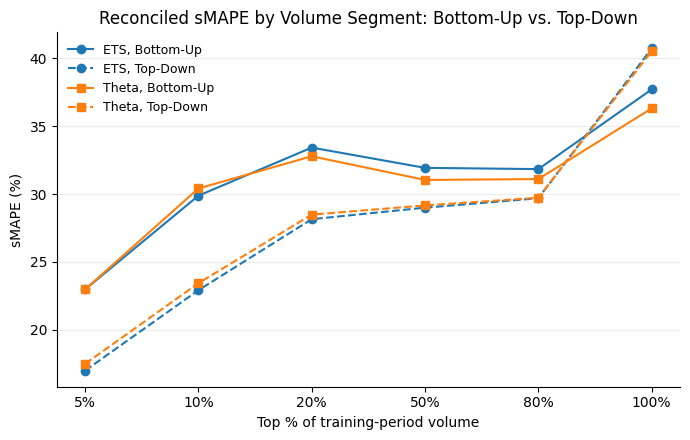

In [23]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))

buckets = volume_results_rec["top_%_of_volume"].astype(str)
x = range(len(buckets))

ax.plot(x, volume_results_rec["ets/BottomUpSparse"],
        marker="o", color="tab:blue", linestyle="-", label="ETS, Bottom-Up")
ax.plot(x, volume_results_rec["ets/TopDownSparse_method-proportion_averages"],
        marker="o", color="tab:blue", linestyle="--", label="ETS, Top-Down")
ax.plot(x, volume_results_rec["theta/BottomUpSparse"],
        marker="s", color="tab:orange", linestyle="-", label="Theta, Bottom-Up")
ax.plot(x, volume_results_rec["theta/TopDownSparse_method-proportion_averages"],
        marker="s", color="tab:orange", linestyle="--", label="Theta, Top-Down")

ax.set_xticks(list(x))
ax.set_xticklabels([b + "%" for b in buckets])
ax.set_xlabel("Top % of training-period volume")
ax.set_ylabel("sMAPE (%)")
ax.set_title("Reconciled sMAPE by Volume Segment: Bottom-Up vs. Top-Down")
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("volumeReconciledChart.png", dpi=200)
plt.show()

**Note on averaging convention.** The by-level evaluation in Section 11
uses `hierarchical_evaluate`, which computes sMAPE per series first and
then averages the per-series values (a **macro-average** - every series
counts equally). `evaluate_volume_buckets` here instead pools every row
in a bucket before computing sMAPE (a **micro-average**). These are not
the same statistic in general - but they coincide here because the
evaluation grid is perfectly balanced: every series contributes exactly
the same 12 test-period rows (Section 6.4 zero-fills every item-store-
month rather than dropping missing periods), so pooling reduces
algebraically to averaging the per-series means. This is confirmed by
the "top 100%" row above matching the Item-level row in Section 11 to
6 decimal places. If a future version of this pipeline used a ragged
panel (e.g. dropped rather than zero-filled missing months), this
equivalence would no longer hold and the two evaluations would need to
be reconciled explicitly.


## 13. Negative Forecast Check

Sales can't be negative, but ETS and Theta are free to predict below zero
if the underlying math (e.g. a downward trend) pushes them there. Section
8.5 now clips every base forecast at 0 before reconciliation runs, so the
`histavg`/`ets`/`theta` columns below are expected to show **zero**
negatives - this check exists to confirm that clipping step actually
worked, not to discover the original problem (the print statements in
Section 8.5 report the pre-clip counts for the record).
`MinTraceSparse(nonnegative=True)` additionally guarantees its own
reconciliation adjustment can't reintroduce a negative value;
`TopDownSparse` is safe by construction (proportions of a non-negative
total are always non-negative); `BottomUpSparse` simply inherits whatever
the (now-clipped) base model produced.


In [24]:
print("\n" + "=" * 80)
print("VALIDATION: Negative Forecast Check")
print("=" * 80)
for base_model in ["histavg", "ets", "theta"]:
    neg = (pred_with_gt[base_model] < 0).sum()
    print(f" {base_model:<8} base negatives: {neg}")
for col in rec_methods:
    neg = (rec_with_gt[col] < 0).sum()
    print(f" {col} negatives: {neg}")



VALIDATION: Negative Forecast Check
 histavg  base negatives: 0
 ets      base negatives: 0
 theta    base negatives: 0
 histavg/BottomUpSparse negatives: 0
 ets/BottomUpSparse negatives: 0
 theta/BottomUpSparse negatives: 0
 histavg/MinTraceSparse_method-wls_struct_nonnegative-True negatives: 0
 ets/MinTraceSparse_method-wls_struct_nonnegative-True negatives: 0
 theta/MinTraceSparse_method-wls_struct_nonnegative-True negatives: 0
 histavg/TopDownSparse_method-proportion_averages negatives: 0
 ets/TopDownSparse_method-proportion_averages negatives: 0
 theta/TopDownSparse_method-proportion_averages negatives: 0


## 14. Sanity Checks

Four quick checks that the pipeline is doing what it claims to, before
trusting any of the numbers above.

**[1] Coherence check.** HistoricAverage is a *linear* forecast - the mean
of a sum equals the sum of means. That makes its base forecasts already
perfectly coherent, *before* any reconciliation runs. So Bottom-Up
(and MinTrace, mostly) applied to HistoricAverage should barely change
anything - if this check shows a big difference, something in the merge
or the reconciliation step is broken. (Note: forecasts must be matched by
`unique_id` **and** `date` before comparing - the two dataframes are not
guaranteed to be in the same row order.)

**[2] Top-Down root check.** With a single "Total" root now in place,
Top-Down reconciliation should never change the top-level forecast - it
can only redistribute it downward. A non-zero result here would mean the
"Total" root fix from Section 2 isn't actually working.

**[3] Fallback rate.** How often ETS/Theta produced exactly the
HistoricAverage forecast at every single horizon - a proxy for "this
series could not be fit, so it fell back to the safety net" (Section 8).

**[4] Top-Down vs. base HistoricAverage, at a non-root level.** Top-Down
redistributes the Total forecast using each series' *historical average
share* of volume - a different quantity from the ratios implied by
HistoricAverage's own independently-fit per-series forecasts. So below
the Total level, these two should genuinely differ; a near-zero result
here would indicate the reconciler is silently not doing anything (e.g.
a no-op on the sparse root, or a merge picking up the wrong column).


In [25]:
print("\n" + "=" * 80)
print("SANITY CHECKS")
print("=" * 80)

# [1] Coherence check - must merge on (id, date) first; the two
# dataframes are not guaranteed to share the same row order.
check1 = pred_test[[id_col, date_col, "histavg"]].merge(
    rec_test[[id_col, date_col, "histavg/BottomUpSparse"]], on=[id_col, date_col],
)
diff = (check1["histavg/BottomUpSparse"] - check1["histavg"]).abs().max()
print(f" [1] HistoricAverage vs BottomUp(HistoricAverage): max diff = {diff:.6f}  (expect ~0)")

# [2] Top-Down must not change the "Total" root.
root_base = pred_test.loc[pred_test[id_col] == "Total", "ets"].to_numpy()
root_td = rec_test.loc[
    rec_test[id_col] == "Total", "ets/TopDownSparse_method-proportion_averages"
].to_numpy()
print(f" [2] Top-Down root check (ETS): max diff = {np.abs(root_td - root_base).max():.6f}  (expect ~0)")

# [3] Fallback rate, counted per series (not per row).
for m in ["ets", "theta"]:
    match = pred_test[m] == pred_test["histavg"]
    same_as_fallback = match.groupby(pred_test[id_col]).all()
    print(f" [3] {m:<6} fell back on {same_as_fallback.sum():,} of {len(same_as_fallback):,} "
          f"series ({same_as_fallback.mean():.2%})")

# [4] Top-Down vs base histavg, at a NON-root level - should NOT be ~0.
# Top-Down redistributes the Total forecast by historical volume share,
# not by the ratios implied by histavg's own per-series forecasts, so at
# any level below Total these should genuinely differ.
diff_nonroot = (
    rec_test["histavg/TopDownSparse_method-proportion_averages"] - pred_test["histavg"]
).abs().max()
print(f" [4] Top-Down vs base histavg (non-root check): max diff = {diff_nonroot:,.2f} (expect >> 0)")



SANITY CHECKS
 [1] HistoricAverage vs BottomUp(HistoricAverage): max diff = 0.146244  (expect ~0)
 [2] Top-Down root check (ETS): max diff = 0.000000  (expect ~0)
 [3] ets    fell back on 699 of 30,354 series (2.30%)
 [3] theta  fell back on 699 of 30,354 series (2.30%)
 [4] Top-Down vs base histavg (non-root check): max diff = 292,505.69 (expect >> 0)


## 15. Optional Visualisation

Plots a handful of series (random by default) with their actual history
and every reconciled forecast overlaid. To look at specific nodes instead
of random ones, pass `ids=[...]` - remember every `unique_id` now starts
with `"Total/"`, e.g. `ids=["Total/CA", "Total/CA/CA_1"]`.


In [26]:
plot_series(
    df=Y_df.query(f"{cat_label_col}.isin(['train', 'test'])").drop(columns=[cat_label_col]),
    forecasts_df=rec_fc.drop(columns=[cat_label_col]),
    time_col=date_col, target_col=target_col,
    max_ids=8, plot_random=True, engine="plotly",
    # ids=["Total/CA", "Total/CA/CA_1"],  # uncomment to pin specific nodes
)


In [27]:
plot_series(
    df=Y_df.query(f"{cat_label_col}.isin(['train', 'test'])").drop(columns=[cat_label_col]),
    forecasts_df=rec_fc.drop(columns=[cat_label_col]),
    time_col=date_col, target_col=target_col,
    max_ids=8, plot_random=True, engine="plotly",
    ids=["Total", "Total/CA/CA_1"],  # uncomment to pin specific nodes
)


## 16. Export Data for the Dashboard

Four Parquet files feed the Streamlit dashboard (`app/streamlit_app.py`):
a lookup table for the dropdown menus, the full actual sales history, and
the base/reconciled forecasts for the test and live horizons.


In [28]:
df[[col_state, col_store, col_cat, col_dept, col_item]].drop_duplicates().to_parquet(
    cfg.DASHBOARD_DATA_DIR / "hierarchy.parquet", index=False
)
Y_df[[id_col, date_col, target_col, cat_label_col]].to_parquet(
    cfg.DASHBOARD_DATA_DIR / "actuals.parquet", index=False
)
pred_with_gt.to_parquet(cfg.DASHBOARD_DATA_DIR / "pred_with_gt.parquet", index=False)
rec_with_gt.to_parquet(cfg.DASHBOARD_DATA_DIR / "rec_with_gt.parquet", index=False)

print(f"\n Dashboard data exported to {cfg.DASHBOARD_DATA_DIR.resolve()}")



 Dashboard data exported to /Users/hemanth_jp/Documents/GitHub/MBIDA_Master_Thesis/Code/artifacts/dashboard_data
